# 나만의 LangGraph AI Agent — 실습

이 노트북은 **직접 타이핑하며 배우기 위한 실습장**입니다.
옆에 원본 `LangGraph_AI_Agent_회사공유.ipynb`를 띄워두고, 각 셀의 `____`(빈칸)와 `# TODO`를 원본을 참고해 채우세요.

## 사용법
1. 이 노트북 커널을 **`Python (ai-agent-class)`** 로 선택합니다. (오른쪽 위 커널 선택)
2. 위에서부터 순서대로 셀을 실행(Shift+Enter)합니다.
3. `____` 가 있는 셀은 **직접 코드를 채운 뒤** 실행합니다. 각 셀에 `# 원본 CELL N 참고` 가 적혀 있어요.
4. 막히면 원본의 해당 셀을 보고, 그래도 안 되면 저(Claude)에게 셀 번호를 알려주세요.

> **핵심 원칙**: 복붙하지 말고 손으로 치세요. `add_edge`, `add_conditional_edges`, State reducer 같은 건 손이 기억해야 진짜 내 것이 됩니다.

## 1. API 키 설정 (그대로 실행)

이 셀은 학습 대상이 아니라 준비 단계라 완성되어 있습니다. 그냥 실행하고 키를 입력하세요.

In [1]:
import os
from getpass import getpass

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("OPENAI_API_KEY not found")

print("OPENAI_API_KEY:", "설정됨" if os.environ.get("OPENAI_API_KEY") else "없음")

OPENAI_API_KEY: 설정됨


## 2. LLM 기초 — 조각들을 익히기

Agent는 결국 아래 조각들의 조합입니다. 하나씩 손으로 만들어 봅니다.

### 2-1. LLM 직접 호출: `invoke()` — 원본 CELL 12 참고

가장 기본. `ChatOpenAI` 객체를 만들고 `.invoke()`로 질문을 던집니다.

In [2]:
# OpenAI 모델을 LangChain 방식으로 다루는 도구를 가져옴
from langchain_openai import ChatOpenAI

# llm 객체 생성: gpt-4o-mini 모델을 사용하며, temperature는 0으로 설정
# 참고로 temperature는 모델의 창의성 정도를 조절하는 파라미터로, 0에 가까울수록 더 결정적인 답변을 생성함
# 즉, 창의성 최소라는 뜻
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# llm 객체를 사용하여 "AI Agent를 한 문장으로 설명해줘"라는 질문을 모델에 전달하고, 그 결과를 response 변수에 저장
response = llm.invoke("AI Agent를 한 문장으로 설명해줘")
print(response.content)

AI Agent는 특정 작업을 수행하거나 문제를 해결하기 위해 독립적으로 행동하고 의사결정을 내리는 인공지능 시스템입니다.


### 2-2. LCEL 기본형: `Prompt | LLM | Parser` — 원본 CELL 14 참고

`|` 파이프로 프롬프트→LLM→파서를 연결하는 게 LangChain의 핵심 문법(LCEL)입니다.

In [3]:
'''
* LCEL = LangChain Expression Language
    - 아래에서 나올 | 파이프로 조각들을 엮는 문법/방식 자체를 부르는 이름
    - 예전에는 체인을 만들 때 복잡한 클래스를 상속받아야 했지만, 이제는 파이프라인처럼 간단하게 체인을 만들 수 있음
    - LCEL 덕분에 prompt | llm | parser 와 같이 레고 블록 끼우듯 직관적으로 연결 가능

* 이게 왜 중요한가?
    - 이 블록을 파이프로 잇는다는 감각이 그대로 확장돼서, 밑에서 배울 LangGraph 도 이걸 한 단계 더 키운다.
    - 단순 일직선 LCEL로는 안 되는 (분기, 병렬, 조건)이 필요할 때 State와 노드/엣지로 엮는것이다.
    - 그래서 지금 이에 대한 감 잡으면 좋다고 한다. (LCEL은 LangGraph의 기초 - by 클로드 Opus 4.8 ㅎ)
'''

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = PromptTemplate.from_template(
    # 여기서 topic이라는 변수를 사용하여, 유치원생에게 설명하는 방식으로 AI Agent를 설명하도록 요청
    # PromptTemplate 은 모델에게 전달할 프롬프트를 구성하는 도구로, 
    # 여기서는 topic이라는 변수를 사용하여 유치원생에게 설명하는 방식으로 AI Agent를 설명하도록 요청
    "{topic}을 처음 배우는 유치원생한테 설명한다 생각하고 3문장 이내로 설명해줘."
)
parser = StrOutputParser()

# 왼쪽 출력을 오른쪽 입력으로 흘려보내라는 뜻 : 리눅스 터미널의 ls | grep 파이프와 같은 개념
# 입력 -> 프롬프트 -> LLM -> 파서 -> 출력
chain = prompt | llm | parser
result = chain.invoke({"topic": "AI Agent"})
print(result)

AI 에이전트는 컴퓨터가 사람처럼 생각하고 문제를 해결하는 도와주는 친구야. 우리가 질문을 하면 대답을 해주고, 게임을 하거나 이야기를 만들어 줄 수 있어. 마치 똑똑한 로봇처럼 우리를 도와주는 거란다!


### 2-3. ChatPromptTemplate: 역할(system/human) 나누기 — 원본 CELL 16 참고

system 프롬프트로 '역할'을, human으로 '질문'을 분리합니다.

In [4]:
'''
* 앞서 2-2 에서 배운 것과 달리, 이번에는 ChatPromptTemplate을 사용하여 대화형 프롬프트를 구성함
    - system : LLM에게 주는 성격, 역할, 행동 지침을 담은 프롬프트 (사용자에겐 안보임)
    - human : 실제 사용자 질문, 여기 {question} 빈칸이, .invoke()로 채워짐
    `from_messages` 에 (역할, 내용) 튜플들을 리스트로 넣는 것이 문법 포인트이다.

* 왜 나눠서 쓰는가?
    - system 에 친절한 강사 / 냉정한 코드 리뷰어 / JSON만 출력하는 봇 등을 심으면, 같은 질문이어도 답변, 톤, 형식이 완전히 달라진다.
    - 실제 챗봇 에이전트는 거의 다 이러한 방식을 사용한다. system에 역할 제약, 출력규칙을 박고, human엔 매번 바뀌는 사용자 입력만 흘려보낸다.
'''

from langchain_core.prompts import ChatPromptTemplate

chat_prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 나에게 AI Agent를 유치원생에게 설명해주듯이 친절하게 해주는 AI Agent강사이다. 명확하고 이해되기 쉽게 설명한다."),
    ("human", "{question}"),
])

chat_chain = chat_prompt | llm | StrOutputParser()

answer = chat_chain.invoke({"question": "Tool과 Agent의 차이를 알려줘"})
print(answer)

좋아! Tool과 Agent의 차이를 쉽게 설명해줄게.

**Tool(도구)**는 우리가 어떤 일을 할 때 사용하는 물건이나 프로그램이야. 예를 들어, 연필은 글씨를 쓰는 도구고, 컴퓨터는 여러 가지 일을 도와주는 도구야. 도구는 우리가 직접 사용해야 하고, 스스로는 아무것도 하지 않아.

**Agent(대리인)**는 스스로 생각하고 행동할 수 있는 존재야. 예를 들어, 로봇 청소기는 우리가 명령을 내리지 않아도 스스로 방을 청소해. 이렇게 스스로 결정을 내리고 행동하는 것이 Agent의 특징이야.

그래서 간단히 말하면, Tool은 우리가 사용하는 도구이고, Agent는 스스로 생각하고 행동하는 존재라고 할 수 있어! 이해했니?


### 2-4. JsonOutputParser: 출력을 구조화(dict)로 — 원본 CELL 18 참고

LLM 답을 문자열이 아니라 파이썬 dict처럼 다루게 만듭니다. Agent가 결과로 분기 판단할 때 중요.

In [5]:
'''
앞선 2-2, 2-3에서 배운 것과 달리, 이번에는 JsonOutputParser를 사용하여 모델의 출력을 JSON 형식으로 파싱함

2-2, 2-3 : 파서 -> StrOutputParser() : 문자열로만 출력됨
2-4 : 파서 -> JsonOutputParser() : JSON으로 출력됨

2-2, 2-3 : 결과 타입 -> 문자열 str
2-4 : 결과 타입 -> 딕셔너리 dict

2-2, 2-3 : 쓸모 -> 사람이 읽기
2-4 : 쓸모 -> 사람이 읽기 + 프로그램이 읽기 (코드로 값 꺼내 판단)
'''

from langchain_core.output_parsers import JsonOutputParser

json_parser = JsonOutputParser()
format_instructions = json_parser.get_format_instructions()

json_prompt = PromptTemplate.from_template(
    "다음 문장을 감정 분석해줘. 반드시 JSON으로만 답해.\n"
    "문장: {review}\n 출력 형식 안내 : {format_instructions}"
)

json_chain = json_prompt | llm | json_parser

parsed = json_chain.invoke({
    "review" : "배송도 빠르고 품질도 좋아서 만족함ㅎㅎ",
    "format_instructions" : format_instructions,
})
print(parsed)
print(type(parsed))  # dict 타입으로 출력됨

{'sentiment': 'positive', 'confidence': 0.95, 'comments': '배송과 품질에 대한 만족감을 표현하고 있음.'}
<class 'dict'>


### 2-5. RunnableParallel: 한 입력을 여러 관점으로 동시에 — 원본 CELL 20 참고

같은 입력을 요약 체인과 키워드 체인에 동시에 흘려 결과를 dict로 모읍니다. (MAS의 병렬 fan-out 감각의 축소판)

In [6]:
'''
* RunnableParallel 은 여러 체인을 병렬로 실행할 수 있는 도구이다.
    - 예를 들어, 하나의 텍스트를 요약하고 동시에 핵심 키워드를 추출하는 작업을 병렬로 수행할 수 있다.
    - 아래 예제에서는 summary_chain과 keyword_chain을 정의하고, RunnableParallel을 사용하여 두 체인을 동시에 실행한다.

* 구조 뜯어보기
    - `summary_chain`, `keyword_chain` : 각각 2-2에서 배운 평범한 LCEL 체인, 하나는 요약, 하나는 키워드 추출
    - `RunnableParallel` : 딕셔너리로 여러 체인을 묶음. key(`summary`, `keywords`) 는 결과를 담을 이름표
    - .invoke({"text" : ...}) : 해당 입력 하나가 두 체인에 똑같이 들어감
'''
from langchain_core.runnables import RunnableParallel

summary_chain = PromptTemplate.from_template(
    "다음 내용을 한 문장으로 요약해줘: {text}"
) | llm | StrOutputParser()

keyword_chain = PromptTemplate.from_template(
    "다음 내용의 핵심 키워드 3개만 쉼표로 출력해줘: {text}"
) | llm | StrOutputParser()

parallel_chain = RunnableParallel({
    "summary": summary_chain,
    "keywords": keyword_chain,
})

parallel_result = parallel_chain.invoke({
    "text": "LangGraph는 State를 중심으로 노드와 엣지를 연결해 에이전트 워크플로우를 구성한다."
})
print(parallel_result)

{'summary': 'LangGraph는 State를 중심으로 노드와 엣지를 연결하여 에이전트 워크플로우를 구성하는 시스템이다.', 'keywords': 'LangGraph, State, 에이전트 워크플로우'}


# 챕터 2를 진행하면서 느낀점

- 내 후기 : Chapter2 에서 천천히 코드 작성해보면서 문득 한가지 의문점이 들었다.
(아래는 단순히 내 생각임 AI 돌린거 아님)
```
"AI Agent 개발에 대해서 공부하고 배우는데 해당 내용을 진행하며 내가 AI AGENT를 사용하긴 한것일까?
그냥 단순히 AI API를 호출한것과 무슨 차이가 있던걸까" 

와 같은 의문이 들었다.

AI 응답을 호출하면서, "흠...이게 AI Agent 기초?" 와 같은 생각이 들면서 잘 체감이 안되었다.
단순히 langchain 만 사용해봐서 그런가? 

그러면 langchain 이 뭘 위해 왜 쓰는걸까?
나는 왜 이런 단순히 AI API 만 호출한것과 같은 의문이 들었던 걸까?

단순히 에이전트가 아닌 웹에서 일반적인 chatgpt 혹은, claude, 등 여러 llm 에서 웹에서 그냥 일반 흠..상호작용? 웹에서 이런것들도 얼마든지 진행할 수 있는데, 과연 내가 chapter2 를 따라 쳐보면서 왜 이런 생각이 들었던 것일까?

아니면 내가 생각한 AI Agent 가 클로드 코드, 코덱스, 이렇게 자동으로 코드를 명령어 만으로 생성해주거나, 혹은 해봤자 코멧 브라우저 혹은 크롬 브라우저에서 자동으로 옆에 어시스턴트를 클릭하면 알아서 뭔가 정보를 찾아주는? 그런걸 에이전트라 생각한 것일까?

내가 너무 AI Agent의 개념에 대해서 너무 시야가 좁았던걸까?
```

...와 같은 의문이 들었다.

---

## 아래는 Claude Code 를 통해 공부하고 배운점

**결론 : "LangChain 으로 LLM 호출하는 법" 까지 배운거고 아직 LangGraph 는 한 줄도 안판 상태이다.**

### 1. 챕터2에서 내가 진행했던 것은 에이전트가 아니다.
- 그저 AI API 호출이 예쁜 배관(plumbing)을 두른 것이다. 이게 웹에서 ChatGPT 치는 거랑 뭐가 다른가? 라는 생각이 들었다.

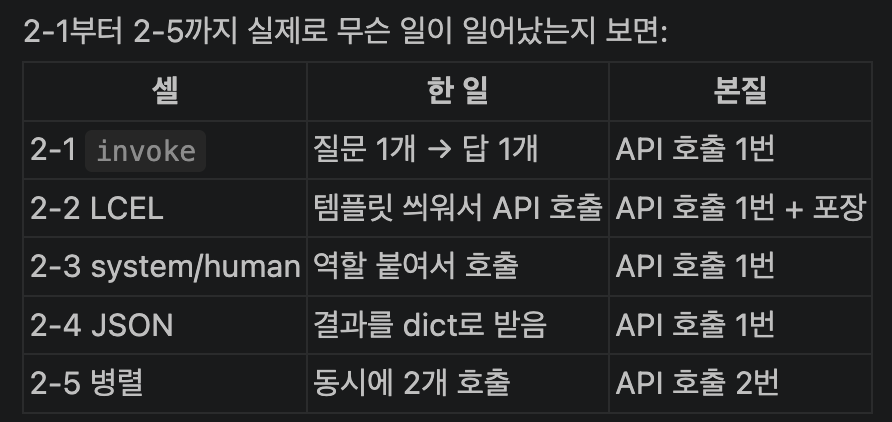

- 전부 보면은 "입력 -> 출력" 이 한 방향으로 고정되어 있다. 내가 흐름을 다 정해놌고, LLM은 그 안에서 그냥 문장만 뱉었다. 스스로 뭘 할지 결정한 적도 없고, 반복(loop)한 적도 없고, 도구를 써서 세상에 뭔가를 한 적도 없다. 즉, AI Agent가 아닌 것이다.

### 2. 그럼 LangChain은 무엇일까?
- LangChain = 에이전트가 아니라, 에이전트를 만들 때 사용하는 부품 상자 (프레임워크) 즉, 레고 블록이지 완성품이 아니다. 
    - Prompt, Parser, LLM 연결, 도구, 메모리, 검색기(retriever) 같은 조각들을 **표준화** 해서 끼우기 쉽게 해주는 도구 모음이다.
    - LCEL (Prompt | llm | parser) 은 그 블록을 잇는 문법이고, 
        - 굳이 비유하자면 FastAPI 같은 것이다. FastAPI 서버 혹은 Spring 서버를 세팅했다고 해서 대단한 서버를 만든 게 아니다. `return "hello"` 한 줄만 써도 FastAPI, Spring 서버를 **"사용한"** 것과 마찬가지이다.
        - 마찬가지로 LangChain 으로 `llm.invoke()` 한 줄 친것은 딱 그 `hello world` 수준이다.

```
LangChain을 사용했다? != 에이전트를 만들었다.
이 둘을 분리해서 이해하는게 핵심이다.
```

### 3. 그러면 에이전트는 뭐가 달랐어야 할까?

에이전트를 가르는 결정적 세 가지

1. 도구 (Tools) - LLM이 말만 하는 게 아니라, (검색, 계산, 파일읽기) 코드실행 같은 행동을 할 수 있다.
2. 루프 (Loop) - 관찰 -> 판단 -> 행동 -> 다시 관찰 을 스스로 반복 해야 한다. (한 방에 안 끝난다.)
3. 제어권이 모델에게 - "다음에 뭘 할지?" 를 네가 코드로 못 박은것이 아니라 LLM이 정한다.

우리가 챕터2에 진행했던 LangChain관련한 내용에서는 이 중 단 하나도 없었다. 그래서 그냥 단순히 AI API 호출과 다를게 없다.

### 4. 에이전트는 사다리다.
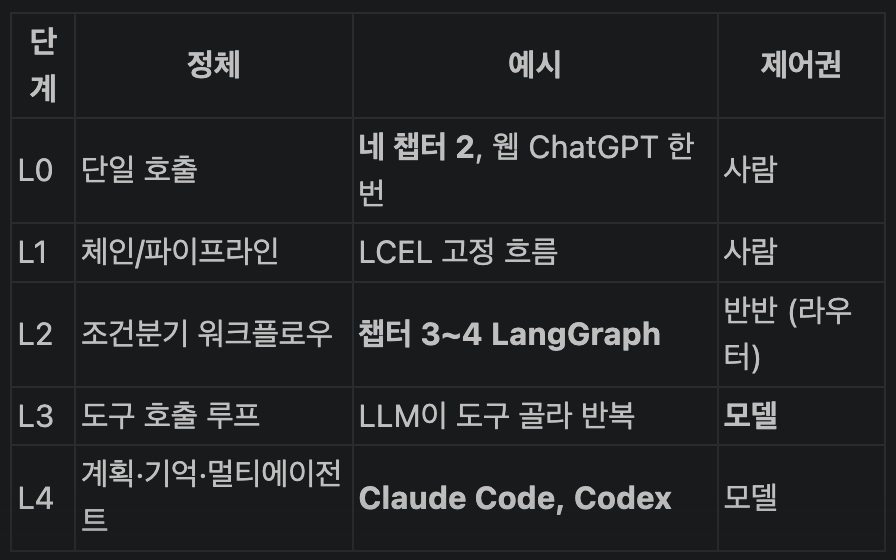

- 나의 개념이 너무 좁았던 것일까? -> 아니다, 오히려 정확했다. Claude Code, Codex, 브라우저 어시스턴트는 진짜 에이전트인 (L3 ~ L4) 가 맞다. 내 머릿속에 그린 에이전트 다운 에이전트의 개념의 방향성은 맞았다.
- 왜 이런 의문이 들었을까? -> 나는 지금 사다리의 맨 아래 (L0)에 있는데? 목표는 맨 위인 (L4)라서 이러한 격차가 느껴졌었다.


## 3. LangGraph 기초 — State와 그래프 3패턴

여기서 **State(TypedDict) + 노드 + 엣지** 감각을 확실히 잡으면 뒤의 MAS가 쉬워집니다.
직렬 → 조건분기 → 병렬 세 패턴을 손으로 만들어 봅니다.

### 3-0. 공통 import (그대로 실행) — 원본 CELL 27 참고

In [9]:
# 챕터 3 ~ 4 공통 import

from typing import Annotated, Sequence  # Annotated: State key에 reducer 규칙을 붙일 때 사용
from typing_extensions import TypedDict   # TypedDict: State의 key와 자료형을 명시

import operator  # operator.add: 병렬 노드 결과 리스트를 이어 붙이는 reducer]

from IPython.display import Image, display
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages

print("LangGraph import 완료")

LangGraph import 완료


### 3-1. 직렬 그래프: retrieve → generate — 원본 CELL 29 참고

노드는 **바뀐 key만** 딕셔너리로 반환하면 LangGraph가 State에 병합해 줍니다.

In [10]:
"""
직렬 그래프 : retrieve -> generate
"""

#1) State = 그래프가 들고 다니는 공유 메모
class SerialState(TypedDict):
    question: str   # 사용자 질문
    context: str    # retrieve가 채움
    answer: str     # generate가 채움

#2) 노드 = state 받아 "바뀐 key만" dict로 return
def retrieve(state: SerialState):
    question = state["question"]

    # 실제로는 아래의 자리가 DB조회 / 문서검색 / API / RAG가 된다
    if "감기" in question:
        context = "감기에는 수분 섭취, 휴식, 따뜻한 차가 도움이 된다."
    else:
        context = "등록된 건강관리 정보가 없습니다."
    return {"context" : context}    # 전체 State가 아니라 바뀐 key만 반환 → 나머지는 LangGraph가 병합


def generate(state: SerialState):
    answer = f"질문: {state['question']}\n근거: {state['context']}"
    return {"answer" : answer}

#3) 배선 : 도화지 -> 노드 등록 -> 엣지 연결 -> 컴파일 -> 실행
builder = StateGraph(SerialState)
builder.add_node("retrieve", retrieve)
builder.add_node("generate", generate)
builder.add_edge(START, "retrieve")        # 시작 → retrieve
builder.add_edge("retrieve", "generate")   # retrieve → generate
builder.add_edge("generate", END)          # generate → 끝
graph = builder.compile()

result = graph.invoke({"question" : "감기 걸렸을 때 어떻게 해야 해?", "context" : "", "answer" : ""})
print(result["answer"])

질문: 감기 걸렸을 때 어떻게 해야 해?
근거: 감기에는 수분 섭취, 휴식, 따뜻한 차가 도움이 된다.


### 3-2. 조건부 분기: lookup → (answer | fallback) — 원본 CELL 31 참고

`add_conditional_edges` 로 라우터 함수의 반환값에 따라 다음 노드를 고릅니다.

### 3-3. 병렬 fan-out 후 합류 — 원본 CELL 33 참고

두 노드가 **동시에** `notes`에 값을 추가합니다. 그래서 State에서 `notes`는
`Annotated[list[str], operator.add]` — 즉 **reducer로 리스트를 이어 붙이도록** 선언해야 합니다.

## 4. 핵심 프로젝트: 로컬 우선 Multi-Agent System

이제 진짜 에이전트입니다. 흐름:

```
entry_node (로컬에 질병명 있나?)
├─ 있으면 → db_agent + csv_agent (병렬) ─┐
└─ 없으면 → web_agent → rag_agent ───────┤
▼
reporter (통합 리포트)
```

### 4-0. 데이터 자동 생성 (그대로 실행) — 원본 CELL 27 참고

SQLite DB와 CSV를 실행 시 자동 생성합니다. 학습 대상 아님, 그냥 실행.

### 4-1. 설정값 (그대로 실행) — 원본 CELL 42 참고

로컬에 정확히 있는 질병 키 목록과, RAG fallback용 내부 문서 샘플입니다.

### 4-2. State 설계 — 원본 CELL 39 참고

MAS 전체가 공유하는 State입니다. **여러 노드가 동시에 추가하는 key**(evidence, used_agents, trace)는
반드시 `Annotated[..., operator.add]` reducer로 선언해야 병렬 실행 시 값이 덮어써지지 않고 이어 붙습니다.

### 4-3. 진입 노드 + 라우터 — 원본 CELL 44 참고

`entry_node`는 질문에 로컬 질병 키가 있는지 보고 `found`를 정합니다.
`route_after_entry`는 있으면 DB/CSV로 **병렬 분기**(리스트 반환!), 없으면 web으로 보냅니다.

### 4-4. DB Agent + CSV Agent — 원본 CELL 46 참고

둘 다 병렬로 실행되어 각자 `evidence`, `used_agents`, `trace`에 자기 결과를 추가합니다.

### 4-5. Web fallback + RAG Agent — 원본 CELL 48, 50 참고

로컬 키가 없을 때의 경로. web_agent는 데모라 바로 RAG로 넘기고, `simple_retrieve`가
토큰 겹침 점수로 내부 문서를 검색합니다.

### 4-6. Reporter 노드 — 원본 CELL 52 참고

수집된 evidence를 하나의 리포트로 합칩니다. 결과는 `messages`에 `AIMessage`로 담습니다.

### 4-7. 그래프 조립 & 컴파일 — 원본 CELL 54 참고

지금까지 만든 노드/라우터를 그래프로 엮는 단계. 여기가 MAS의 뼈대입니다.

### 4-8. 그래프 시각화 (그대로 실행) — 원본 CELL 56 참고

### 4-9. 실행 1 — 로컬 데이터가 있는 경우 (DB/CSV 병렬 경로) — 원본 CELL 59 참고

### 4-10. 실행 2 — 로컬 키가 없어 RAG로 보강하는 경우 — 원본 CELL 61 참고

"혈압"이라고만 물으면 정확한 키("고혈압")가 아니라서 web→rag 경로를 탑니다.

### 4-11. 경로 검증 테스트 (그대로 실행) — 원본 CELL 65 참고

내가 조립한 그래프가 의도대로 흐르는지 자동 검증합니다. **`검증 통과`가 떠야 성공!**

## 5. 완성! 그리고 다음 단계

여기까지 채웠다면 **LLM 조각 → LangGraph 3패턴 → 로컬 우선 MAS** 를 직접 손으로 만든 겁니다.

### 이제 '나만의 에이전트'로 바꿔보기 (도전 과제)
1. **데이터 바꾸기**: `ensure_demo_data`의 질병/식단 대신 내 관심 주제(예: 사내 FAQ, 장비 매뉴얼)로 교체
2. **노드 추가**: reporter 앞에 LLM으로 문장을 다듬는 노드 추가 (원본 CELL 63 참고)
3. **RAG 고도화**: `simple_retrieve`를 실제 임베딩+벡터DB로 교체 (원본 13장 Hybrid Search/RRF 참고)
4. **Human-in-the-loop**: 사람이 승인/수정하는 단계 추가 (원본 18장 기상청 예제 참고)

### 원본의 심화 파트 (다 만든 뒤 읽어보기)
- 13장: Hybrid Search & RRF
- 14장: Tool Observability
- 15장: Golden Test & LLM-as-Judge
- 18장: Human-in-the-loop

막히는 셀이 있으면 셀 제목(예: "4-7")을 알려주세요. 같이 풀어봅시다. 